In [300]:
# Photopeak cut finder
import numpy as np
import os
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import curve_fit
import pandas as pd

event_counts = np.fromfile(r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\event_counts.bin', dtype = np.int32)
event_counts = event_counts.reshape((3072, 3072))
def countidl(idl):
    return np.sum(event_counts[idl])
def countidr(idr):
    return np.sum(event_counts[:,idr])

data_dir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\compressed.bin'
num_rows = os.path.getsize(data_dir) // 10
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, 5))
print(num_rows)

bins = np.linspace(1000, 3500, 200)

1243536940


In [180]:
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

def gaussiannoise(x, a, mu, c, noise):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + noise

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(lor_coincs):
    bins = np.linspace(0, 5000, 100) # Modification: int16s used from file_chunker.py require x100 on upper energy bound
    valuesL = np.histogram(lor_coincs[:,0], bins = bins)[0] # valuesL are to be fitted
    valuesR = np.histogram(lor_coincs[:,1], bins = bins)[0] # valuesR are to be fitted
    # Binning will be same for both so just define bin centers once w.r.t. binsR
    bin_centers = [(bins[q] + bins[q+1])/2 for q in range(0,len(bins)-1)]
                
    # Find the photopeak within 3 bins starting from the RHS of the graph
    for i in range(1, len(valuesR)-4):
        PhotopeakR = 0
        if valuesR[-1*i] > valuesR[-1*(i+1)] and valuesR[-1*i] > valuesR[-1*(i+2)] and valuesR[-1*i] > valuesR[-1*(i+3)] and valuesR[-1*(i+1)] != 0 and valuesR[-1*i] >= 4:
            PhotopeakR = len(valuesR)-1*i
            break
    for i in range(1, len(valuesL)-4):
        PhotopeakL = 0
        if valuesL[-1*i] > valuesL[-1*(i+1)] and valuesL[-1*i] > valuesL[-1*(i+2)] and valuesL[-1*i] > valuesL[-1*(i+3)] and valuesL[-1*(i+1)] != 0 and valuesL[-1*i] >= 4:
            PhotopeakL = len(valuesL)-1*i
            break
                
    fitR_p = [0,1,1] # Initialized to amplitude=0, mean=1, sigma=1
    fitL_p = [0,1,1]
    # Set the range of x and y values to fit: from 3 bins to the left of the photopeak, up to the end of the spectra
    fitR_x = list(bin_centers[PhotopeakR-5:PhotopeakR+10])
    fitL_x = list(bin_centers[PhotopeakL-5:PhotopeakL+10])
    #print(fitR_x[0], fitL_x[0])
    fitR_y = list(valuesR[PhotopeakR-5:PhotopeakR+10])
    fitL_y = list(valuesL[PhotopeakL-5:PhotopeakL+10])

    # Make sure fit ranges are non-empty, perform the fits, keep parameters
    if len(fitR_y) != 0 and len(fitR_x) != 0:
        try:
            fitR_p, fitR_co = curve_fit(gaussian, fitR_x, fitR_y, p0 = [max(fitR_y), fitR_x[fitR_y.index(max(fitR_y))], 100])
        except:
            pass
    # Repeat the fit for the left charge spectrum
    if len(fitL_x) != 0 and len(fitL_y) != 0:
        try:
            fitL_p, fitL_co = curve_fit(gaussian, fitL_x, fitL_y, p0=[max(fitL_y), fitL_x[fitL_y.index(max(fitL_y))], 100])
        except:
            pass
    return fitR_p, fitL_p

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeakL(lor_coincs):
    valuesL = np.histogram(lor_coincs, bins = bins)[0] # valuesL are to be fitted
    # Binning will be same for both so just define bin centers once w.r.t. binsR
    bin_centers = [(bins[q] + bins[q+1])/2 for q in range(0,len(bins)-1)]
                
    # Find the photopeak within 3 bins starting from the RHS of the graph
    for i in range(1, len(valuesL)-4):
        PhotopeakL = 0
        if valuesL[-1*i] > valuesL[-1*(i+1)] and valuesL[-1*i] > valuesL[-1*(i+2)] and valuesL[-1*i] > valuesL[-1*(i+3)] and valuesL[-1*(i+1)] != 0 and valuesL[-1*i] >= 0.4 * np.max(lor_coincs):
            PhotopeakL = len(valuesL)-1*i
            break
    fitL_p = [0,1,1]
    fitL_x = list(bin_centers[PhotopeakL-5:PhotopeakL+10])
    fitL_y = list(valuesL[PhotopeakL-5:PhotopeakL+10])

    if len(fitL_x) != 0 and len(fitL_y) != 0:
        try:
            fitL_p, fitL_co = curve_fit(gaussian, fitL_x, fitL_y, p0=[max(fitL_y), fitL_x[fitL_y.index(max(fitL_y))], 100])
        except:
            pass
    return fitL_p

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeakR(lor_coincs):
    valuesR = np.histogram(lor_coincs, bins = bins)[0] # valuesL are to be fitted
    # Binning will be same for both so just define bin centers once w.r.t. binsR
    bin_centers = [(bins[q] + bins[q+1])/2 for q in range(0,len(bins)-1)]
                
    # Find the photopeak within 3 bins starting from the RHS of the graph
    for i in range(1, len(valuesR)-4):
        PhotopeakL = 0
        if valuesR[-1*i] > valuesR[-1*(i+1)] and valuesR[-1*i] > valuesR[-1*(i+2)] and valuesR[-1*i] > valuesR[-1*(i+3)] and valuesR[-1*(i+1)] != 0 and valuesR[-1*i] >= 0.4 * np.max(lor_coincs):
            PhotopeakL = len(valuesR)-1*i
            break
    fitL_p = [0,1,1]
    fitL_x = list(bin_centers[PhotopeakL-5:PhotopeakL+10])
    fitL_y = list(valuesR[PhotopeakL-5:PhotopeakL+10])

    if len(fitL_x) != 0 and len(fitL_y) != 0:
        try:
            fitL_p, fitL_co = curve_fit(gaussian, fitL_x, fitL_y, p0=[max(fitL_y), fitL_x[fitL_y.index(max(fitL_y))], 100])
        except:
            pass
    return fitL_p

# Function for cutting on photopeak, modified from ChannelPairBuilder.py
# returns an array of only time differences (discard energy information after use)
def cutOnPhotopeak(lor_coincs, fitR_p, fitL_p):
    
    temp = np.asarray(lor_coincs)
    # Use the fitted mean and sigma to define an energy cut based on the photopeaks
    # Cut value is define to be 2.5 sigma below (to the left of) the mean
    R_cut = fitR_p[1] - 2.5*fitR_p[2]
    L_cut = fitL_p[1] - 2.5*fitL_p[2]
    # Only keep events with energies equal to or above the cut values
    temp = temp[temp[:,0] >= L_cut]
    temp = temp[temp[:,1] >= R_cut]
    
    return np.asarray(temp[:,2])

# Function for calculating mean offset for one LOR
# returns mean offset, number of passing events
def calculateMeanOffset(lor_time_diffs):
    # Create histogram
    counts, bins = np.histogram(lor_time_diffs, bins = np.linspace(-2500, 2500, 50))
    bin_centers = [(bins[q] + bins[q+1])/2 for q in range(0,len(bins)-1)]
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    maxindex = np.where(counts == np.max(counts))[0][0]
    initmu = bin_centers[maxindex]
    # Fit range
    bl, br = maxindex - 10, maxindex + 10
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bin_centers[bl:br], counts[bl:br], p0 = [inita, initmu, 500])[0]
        #print(popt)
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # Return mean offset, number of passing events
            return popt[1] #, sum(counts[bl:br])
    except:
        return 0

# Function for calculating mean of mean offsets for one channel
def calculateMeanMeanOffset(mean_offsets):
    # Create histogram
    counts, bins = np.histogram(mean_offsets, bins = np.linspace(-2500, 2500, 50))
    bin_centers = [(bins[q] + bins[q+1])/2 for q in range(0,len(bins)-1)]
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    maxindex = np.where(counts == np.max(counts))[0][0]
    initmu = bin_centers[maxindex]
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bin_centers, counts, p0 = [inita, initmu, 100])[0]
        print(popt)
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # Return mean offset, number of passing events
            return popt[1] #, sum(counts[bl:br])
    except:
        return 0

# Read map
map = pd.read_csv('C:/Users/burri/Downloads/TPPT_Scanner_map.csv', usecols=[0,1,2], header=None)
map = map.to_numpy()
# Get geometric time offset for idl and idr channels to be added to time difference
def geometric_time_offset(idl, idr):
    xL, yL, zL = map[idl + 3072]
    xR, yR, zR = map[idr]
    # Get midpoint between two channels
    mX, mY, mZ = (xL+xR)/2, (yL+yR)/2, (zL+zR)/2

    # If midpoint lies on x = 0, return 0
    if mX == 0:
        return 0
    # else need to calculate distance between x = 0 and midpoint along LOR
    else:
        # Parameterize, below are slopes with x being the parameter
        ay, az = (yR-yL)/(xR-xL), (zR-zL)/(xR-xL)
        # Find y and z for positive distance xL away from xL (y0,z0 at x = 0)
        y0, z0 = yL + ay * -1 * xL, zL + az * -1 * xL
        # Distance, converted to light picoseconds
        d = ((mX)**2 + (y0-mY)**2 + (z0-mZ)**2)**0.5 / 0.299792458 #mm/ps
        # Find direction (midpoint left or right of x=0)
        if -1 * xL > xR:
            return -1 * d
        else:
            return d


In [103]:
chunknum = 26
chunksize = 64
chunkidls = range(chunknum * chunksize, (chunknum + 1) * chunksize)
backadj = chunknum * chunksize

chunkchannelevents = [np.zeros(countidl(chunkidls[idl - backadj]), dtype = np.int16) for idl in chunkidls]
writeheads = np.zeros(chunksize, dtype=np.int32)

for i in tqdm(range(0, num_rows, 1000000)):
    for idl in chunkidls:
        chunk = data[i:i+1000000] 
        chunk = chunk[chunk[:,1] == idl] # Get chunk with only idl
        chunk = chunk[:, 0] # 
        chunkchannelevents[idl - backadj][writeheads[idl - backadj]:writeheads[idl - backadj] + len(chunk)] = chunk
        writeheads[idl - backadj] += len(chunk)



100%|██████████| 1244/1244 [06:18<00:00,  3.29it/s]


In [261]:
chunknum = 26
chunksize = 64
chunkidrs = range(chunknum * chunksize, (chunknum + 1) * chunksize)
backadj = chunknum * chunksize

chunkchannelevents = [np.zeros(countidr(chunkidrs[idr - backadj]), dtype = np.int16) for idr in chunkidrs]
writeheads = np.zeros(chunksize, dtype=np.int32)

for i in tqdm(range(0, num_rows, 1000000)):
    for idr in chunkidrs:
        chunk = data[i:i+1000000] 
        chunk = chunk[chunk[:,3] == idr] # Get chunk with only idl
        chunk = chunk[:, 2] # 
        chunkchannelevents[idr - backadj][writeheads[idr - backadj]:writeheads[idr - backadj] + len(chunk)] = chunk
        writeheads[idr - backadj] += len(chunk)



100%|██████████| 1244/1244 [05:10<00:00,  4.00it/s]


In [19]:
bytesum = 0
countsum = 0
for l in chunkchannelevents:
    bytesum += l.nbytes
    countsum += len(l)
print(bytesum, countsum)

24633312 12316656


371518
[14779.97595205  2324.51338195    57.18127706]


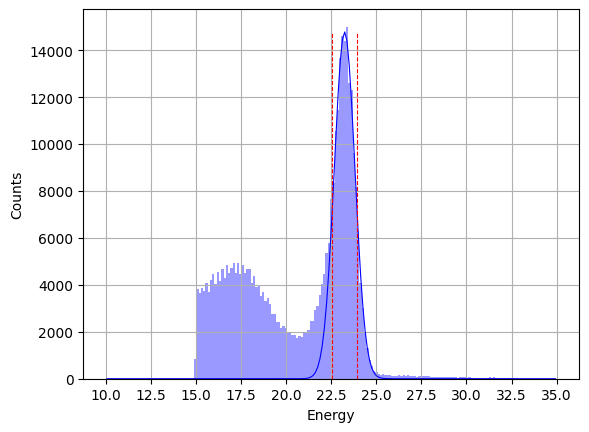

In [314]:
n = 49
print(len(chunkchannelevents[n]))
hist = plt.hist(chunkchannelevents[n], bins = bins, color = 'blue', alpha = 0.4)
fitL = findPhotopeakR(chunkchannelevents[n])
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]
plt.plot(bincenters, gaussian(bincenters, *fitL), color = 'blue', linewidth = 0.8)
print(fitL)
plt.plot([fitL[1] - 2.355/2 * fitL[2], fitL[1] - 2.355/2 * fitL[2]], [0, fitL[0]], color = 'red', linestyle = 'dashed', linewidth = 0.8)
plt.plot([fitL[1] + 2.355/2 * fitL[2], fitL[1] + 2.355/2 * fitL[2]], [0, fitL[0]], color = 'red', linestyle = 'dashed', linewidth = 0.8)

plt.ylabel('Counts')
plt.xlabel('Energy')
plt.xticks([1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500], ['10.0', '12.5', '15.0', '17.5', '20.0', '22.5', '25.0', '27.5', '30.0', '32.5', '35.0'])
plt.grid()
plt.show()